| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 6** | **Fundamental Convolution Application** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie <br> Jimenez, Christian Joros R.  |
| **Section:** | CPE41S2 |
| **Date Performed:** | 4 September 2026 |
| **Date Submitted:** | 4 September 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to introduce the convolutional process by demonstrating with the programmatic processing of both arbitrarily generated signals and collected data using simple convolution techniques.

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program that manipulates signals with convolutional processing with simple response signals.

## 3. Discussion


In mathematics (in particular, functional analysis), convolution is a mathematical operation on two functions (f and g) that produces a third function (f*g) that expresses how the shape of one is modified by the other. The term convolution refers to both the result function and to the process of computing it. It is defined as the integral of the product of the two functions after one is reversed and shifted. The integral is evaluated for all values of shift, producing the convolution function.

Convolution has applications that include probability, statistics, acoustics, spectroscopy, signal processing and image processing, engineering, physics, computer vision and differential equations.

The convolution can be defined for functions on Euclidean space and other groups.For example, periodic functions, such as the discrete-time Fourier transform, can be defined on a circle and convolved by periodic convolution. A discrete convolution can be defined for functions on the set of integers.

Generalizations of convolution have applications in the field of numerical analysis and numerical linear algebra, and in the design and implementation of finite impulse response filters in signal processing. Computing the inverse of the convolution operation is known as deconvolution.

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

### 1. Programatically generate the following signals from index [-20,20]:

* A delta function

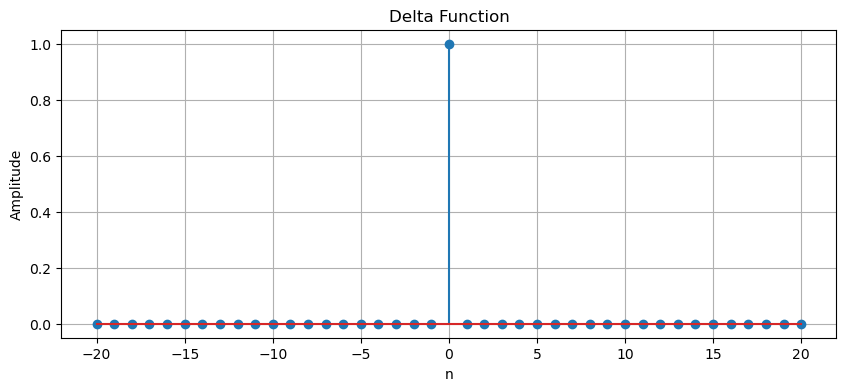

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Define the index range [-20, 20]
n = np.arange(-20, 21)

# Delta function
delta = np.zeros_like(n, dtype=float)
delta[n == 0] = 1.0

plt.figure(figsize=(10, 4))
plt.stem(n, delta)
plt.title('Delta Function')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

* An exponential signal with negative "a"

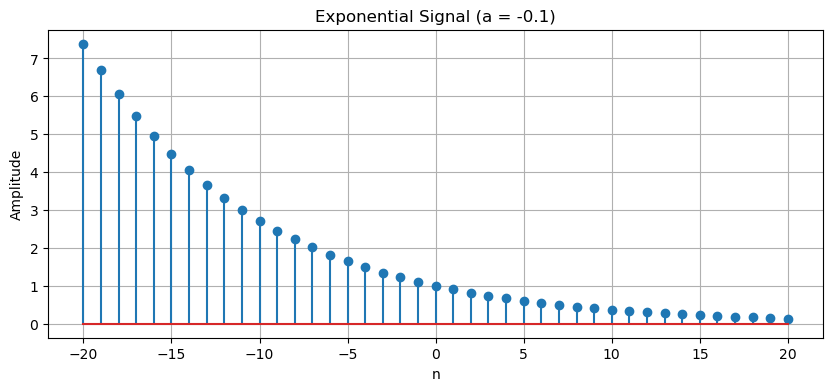

In [16]:
# Exponential signal with negative "a" (a = -0.1)
a = -0.1
exponential = np.exp(a * n)

plt.figure(figsize=(10, 4))
plt.stem(n, exponential)
plt.title('Exponential Signal (a = -0.1)')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

* A ramp signal

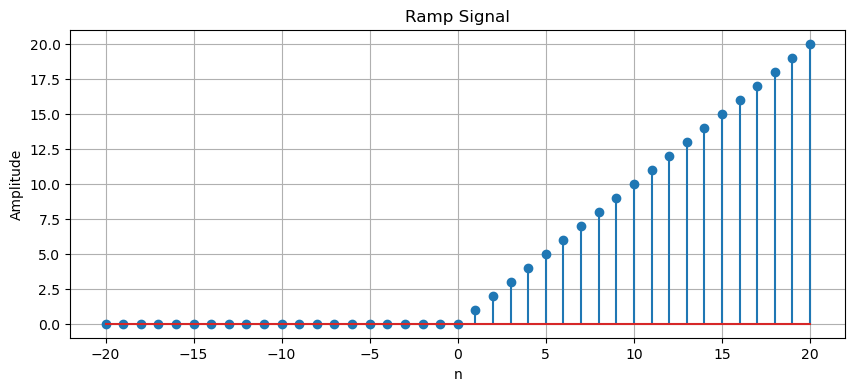

In [17]:
# Ramp signal
ramp = np.maximum(0, n)

plt.figure(figsize=(10, 4))
plt.stem(n, ramp)
plt.title('Ramp Signal')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

* A sinusoidal wave with 0.05 Hz and unit amplitude

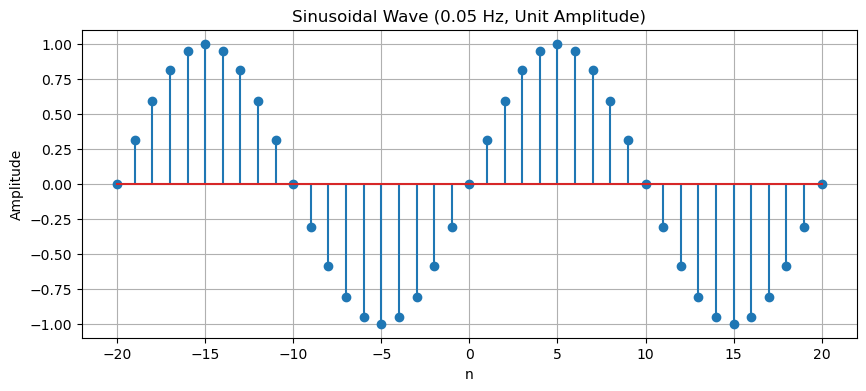

In [18]:
# Sinusoidal wave with 0.05 Hz and unit amplitude
freq = 0.05
amplitude = 1.0
sinusoidal = amplitude * np.sin(2 * np.pi * freq * n)

plt.figure(figsize=(10, 4))
plt.stem(n, sinusoidal)
plt.title('Sinusoidal Wave (0.05 Hz, Unit Amplitude)')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### 2. Add noise to each signal using `np.random` between 0-1. Then plot the four generated signals.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility

"""Randomization 
# np.random.uniform(0, 1, size=len(n)) generates 41 random values
# (one for each index in [-20, 20]) from a uniform distribution between 0 and 1.
# Each random value is independent and uniformly distributed, meaning every value
# between 0 and 1 has equal probability of being selected.
# The seed=42 ensures the same random values are generated each time for reproducibility.
# Each subsequent call to np.random.uniform continues the sequence from the seeded RNG state.
# The noise is additive: noisy_signal[n] = original_signal[n] + random_value[n]
# This simulates real-world sensor noise or measurement uncertainty.
# Since the uniform distribution is flat (unlike Gaussian), noise values are equally
# likely anywhere in [0, 1], creating a "flat" noise floor that affects all signal
# levels equally. For the sinusoidal signal (range -1 to 1), noise shifts it to (-1, 2),
# demonstrating how additive noise can distort both amplitude and DC offset.
"""

# Store all signals and noisy signals
signals = {
    'Delta': delta,
    'Exponential': exponential,
    'Ramp': ramp,
    'Sinusoidal': sinusoidal
}

noisy_signals = {}
for name, sig in signals.items():
    noise = np.random.uniform(0, 1, size=len(n))
    noisy_signals[name] = sig + noise

# Plot individual noisy signals
for name, sig in noisy_signals.items():
    plt.figure(figsize=(10, 4))
    plt.stem(n, sig)
    plt.title(f'{name} Signal + Noise')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

# Combined 2x2 visualization of all noisy signals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('All Noisy Signals', fontsize=16)

for ax, (name, sig) in zip(axes.flatten(), noisy_signals.items()):
    ax.stem(n, sig)
    ax.set_title(f'{name} Signal + Noise')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)

plt.tight_layout()
plt.savefig('outputs/2_all_noisy_signals.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Perform a convolution using summation formula (not using `np.convolve` or any libraries) for four generated signals using the following impulse response with values A = [0, 0, 0, 1, 0, 0, 0]. Plot and save the images.

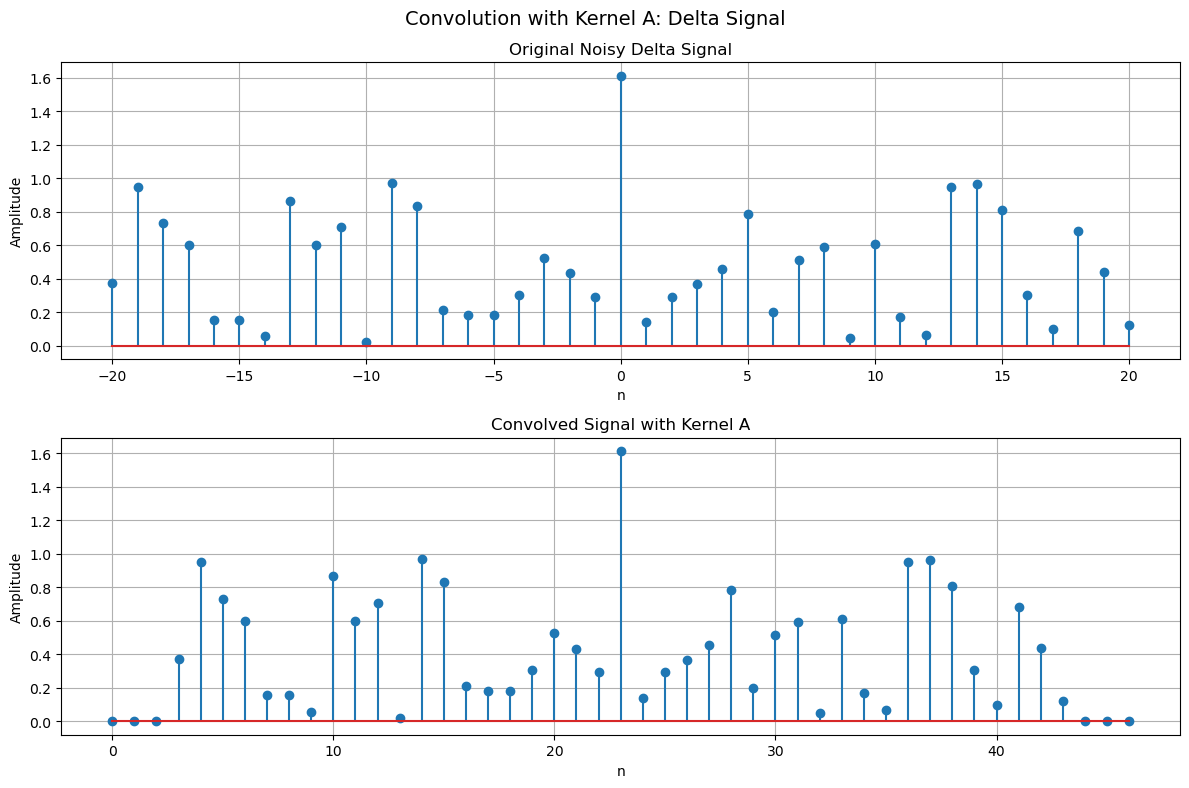

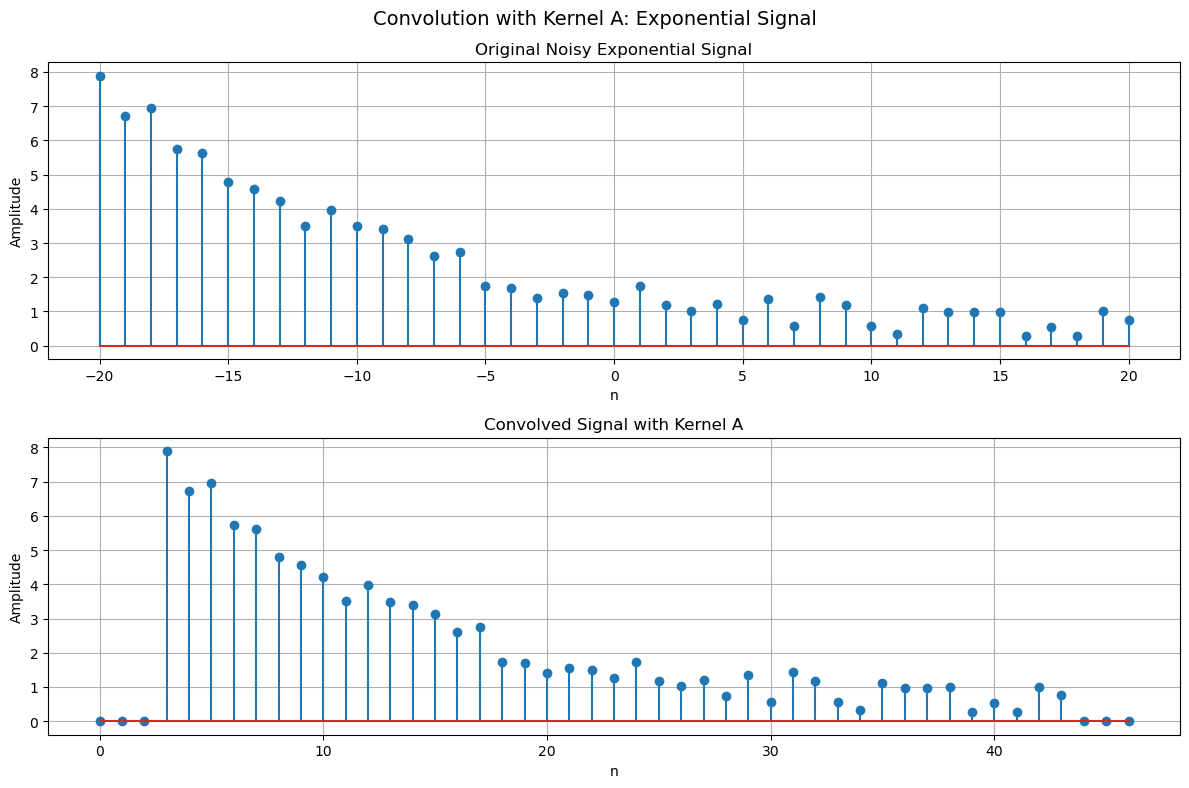

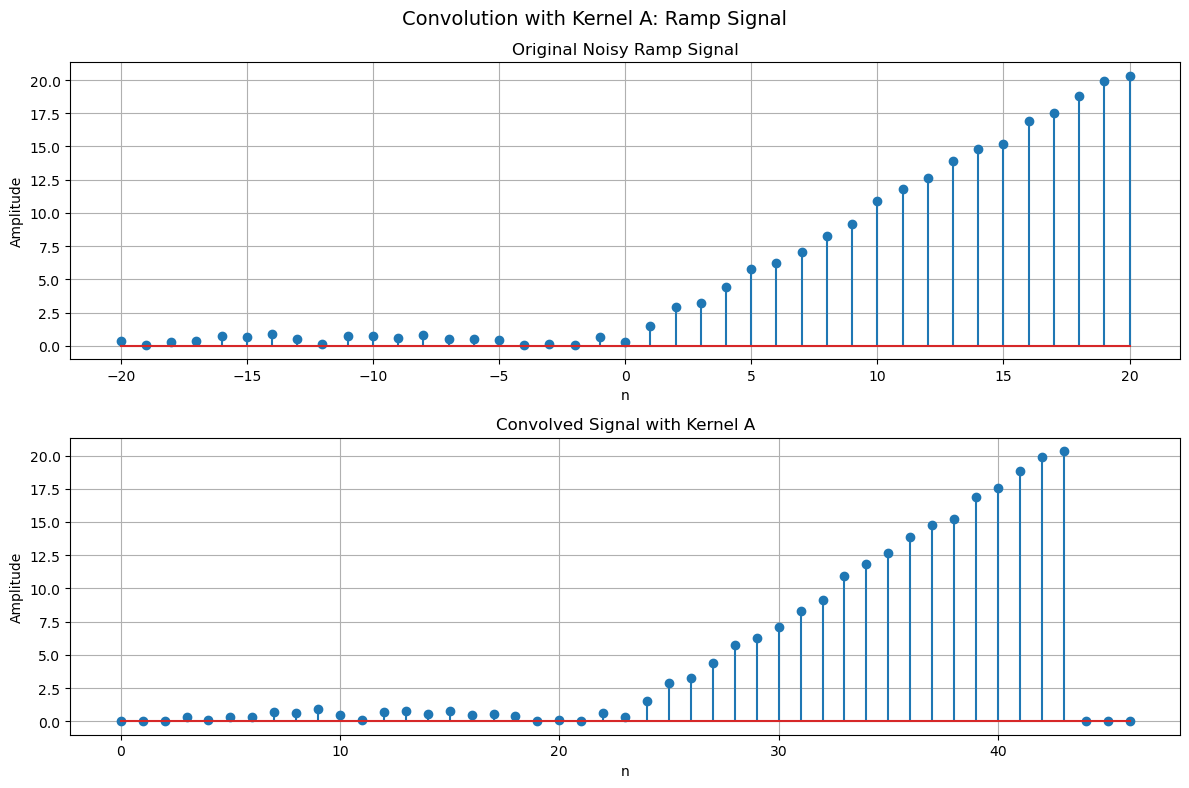

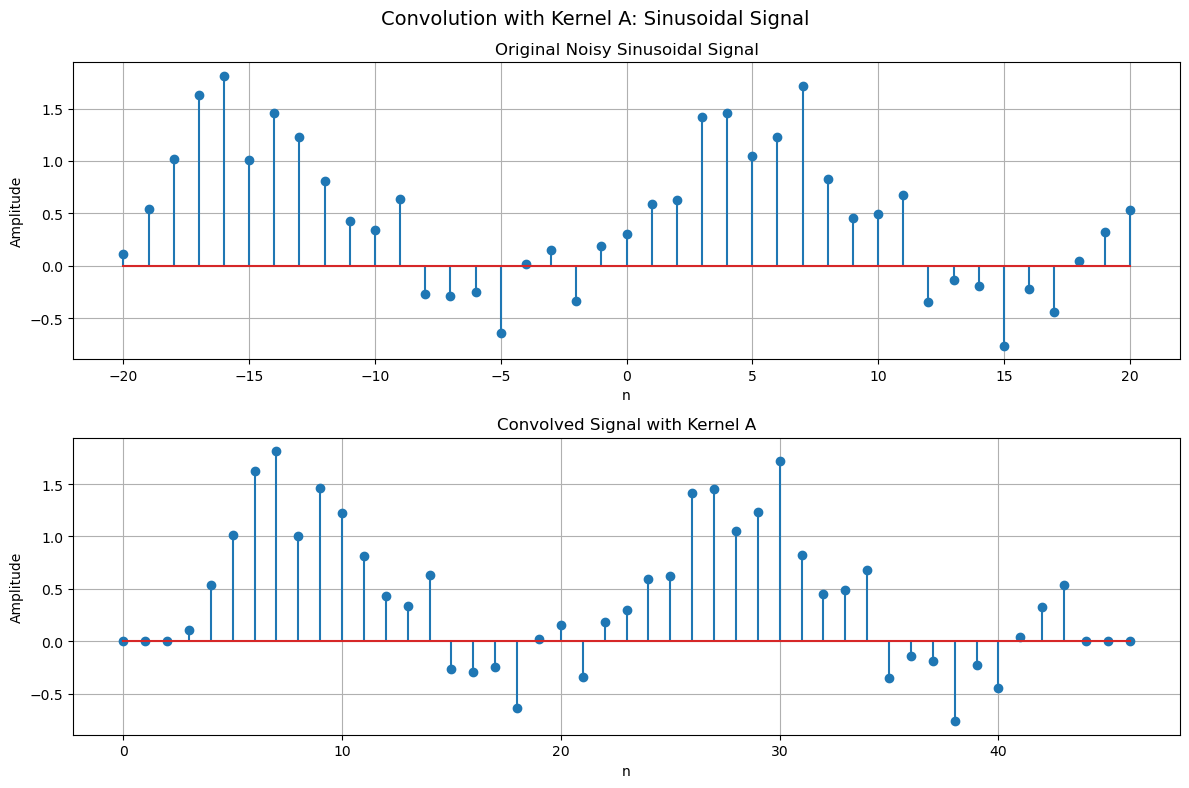

In [23]:
def convolve(x, h):
    """
    Perform convolution using summation formula (not using np.convolve).
    
    Convolution Formula: y[n] = sum_{k} x[k] * h[n-k]
    
    This implements discrete convolution by:
    1. Flipping the kernel h (time reversal): h[-k]
    2. Shifting the flipped kernel across signal x: h[n-k]
    3. Multiplying overlapping samples and summing: sum(x[k] * h[n-k])
    
    Parameters:
    - x: input signal (length nx)
    - h: impulse response/kernel (length nh)
    
    Returns:
    - y: convolved signal (length nx + nh - 1)
    """
    nx = len(x)
    nh = len(h)
    ny = nx + nh - 1
    y = np.zeros(ny)
    x_padded = np.pad(x, (nh-1, nh-1), mode='constant')
    h_flipped = h[::-1]
    for i in range(ny):
        y[i] = np.sum(x_padded[i:i+nh] * h_flipped)
    return y

# Define impulse response A (Delta function - acts as identity filter)
A = np.array([0, 0, 0, 1, 0, 0, 0])
os.makedirs('outputs/kernel_A', exist_ok=True)

# Convolve each noisy signal with kernel A
signals = {'delta': noisy_delta, 'exponential': noisy_exponential, 
           'ramp': noisy_ramp, 'sinusoidal': noisy_sinusoidal}

convolved_signals_A = {}
for name, signal in signals.items():
    convolved = convolve(signal, A)
    convolved_signals_A[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel A: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel A (Identity Filter)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_A/convolution_{name}_kernelA.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel A: [0, 0, 0, 1, 0, 0, 0] — Identity Filter', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_A.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/3_kernel_A_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel A is a delta function `[0, 0, 0, 1, 0, 0, 0]`. When convolved with any signal, it acts as an **identity filter** — the output is identical to the input, shifted by 3 samples. This is because the single '1' at the center selects only the overlapping input sample without modification.

**Comparison to original signals:**
- **Delta:** The sharp spike is preserved exactly (shifted +3). No distortion, no smoothing.
- **Exponential:** The noisy decay curve is preserved (shifted +3). The noise pattern remains unchanged.
- **Ramp:** The linear rise with noise is preserved (shifted +3). The slope and noise are identical.
- **Sinusoidal:** The oscillation with noise is preserved (shifted +3). Frequency and amplitude are unchanged.

**Key takeaway:** Kernel A confirms the convolution implementation is correct — the output matches the input with only a time shift. It introduces zero filtering or distortion.

### 4. Repeat the same process of the following kernels:

#### B = [1, 1, 1, 1, 1, 1, 1]



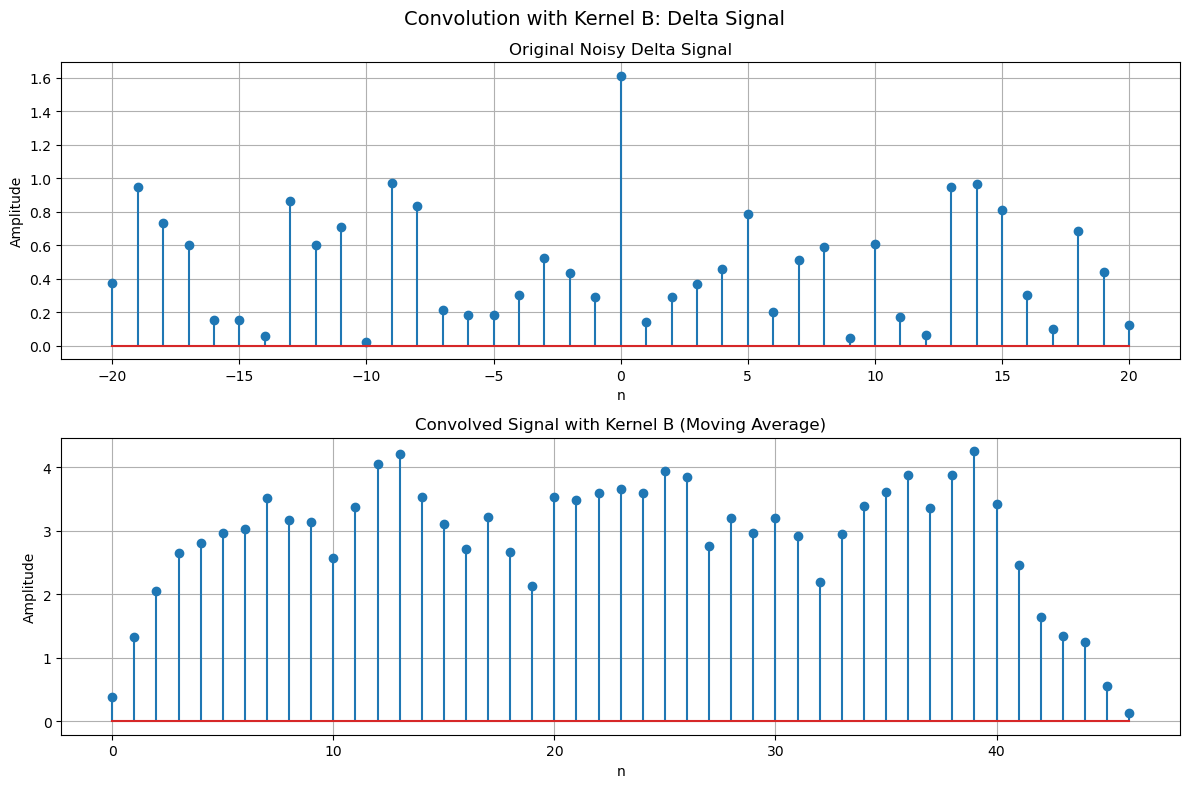

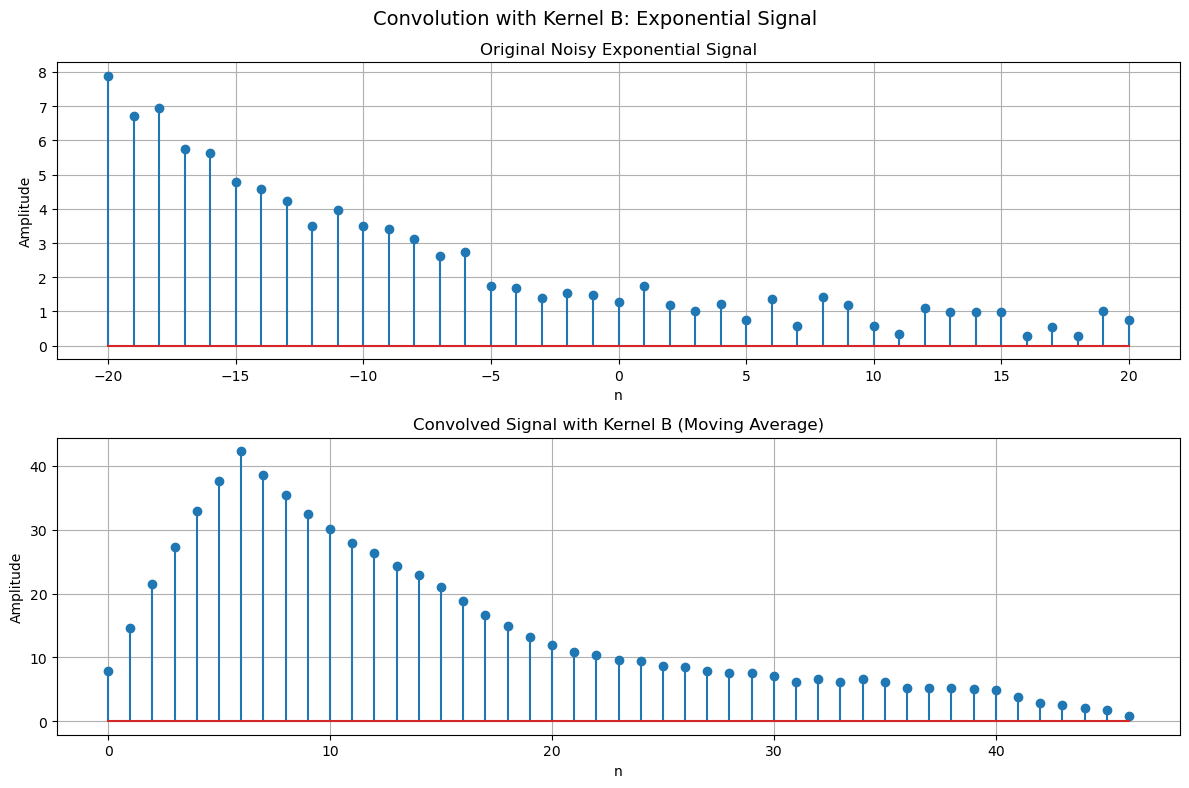

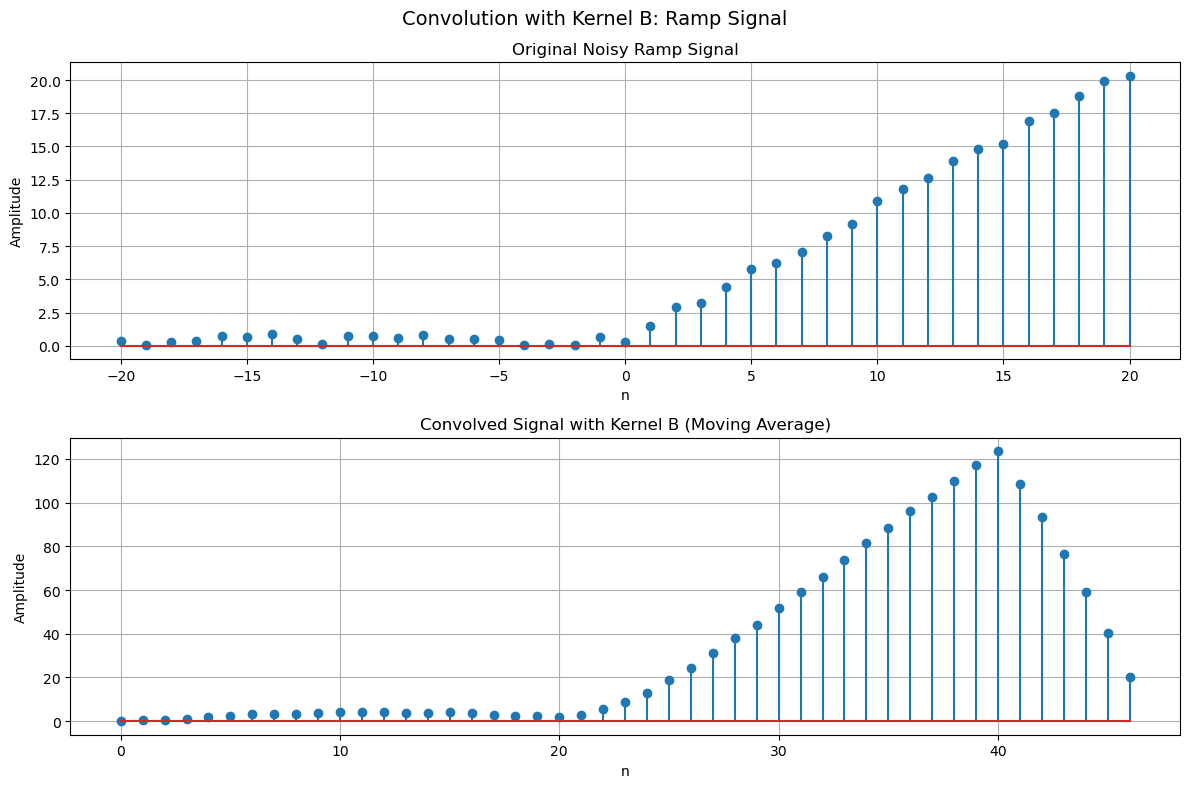

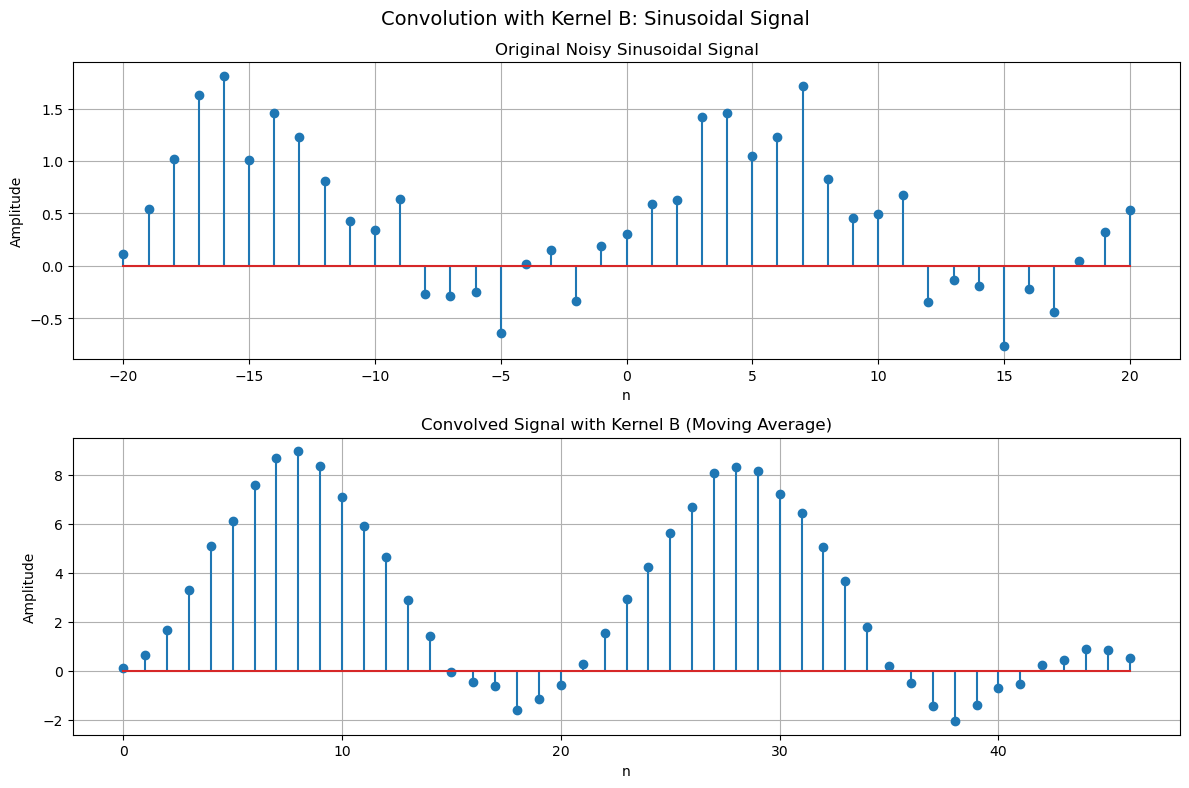

In [24]:
# Define impulse response B (Moving Average)
B = np.array([1, 1, 1, 1, 1, 1, 1])
os.makedirs('outputs/kernel_B', exist_ok=True)

# Convolve each noisy signal with kernel B
convolved_signals_B = {}
for name, signal in signals.items():
    convolved = convolve(signal, B)
    convolved_signals_B[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel B: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel B (Moving Average)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_B/convolution_{name}_kernelB.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel B: [1, 1, 1, 1, 1, 1, 1] — Moving Average', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_B.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/4_kernel_B_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel B `[1, 1, 1, 1, 1, 1, 1]` is a **moving average filter**. Each output sample is the sum of 7 neighboring input samples (equivalent to averaging when normalized). This is a **low-pass filter** that smooths the signal by suppressing high-frequency noise.

**Comparison to original signals:**
- **Delta:** The sharp spike becomes a broad, flat-topped bump spread across 7 samples. The impulse is "smeared" — the sharp transition is lost.
- **Exponential:** The noisy decay becomes smoother. Random fluctuations are averaged out, revealing the underlying exponential trend more clearly.
- **Ramp:** The noisy linear rise becomes a cleaner ramp. Step-like noise is reduced, but the sharp corners at the ramp's start are blurred.
- **Sinusoidal:** The oscillation is preserved but with reduced amplitude variation. High-frequency noise is smoothed out, making the wave appear cleaner.

**Key takeaway:** Effective noise reduction, but at the cost of **blurring sharp edges and transitions**. The trade-off between smoothing and detail preservation is clearly visible.

#### C = [-1, -1, -1, -1, -1, -1, -1]


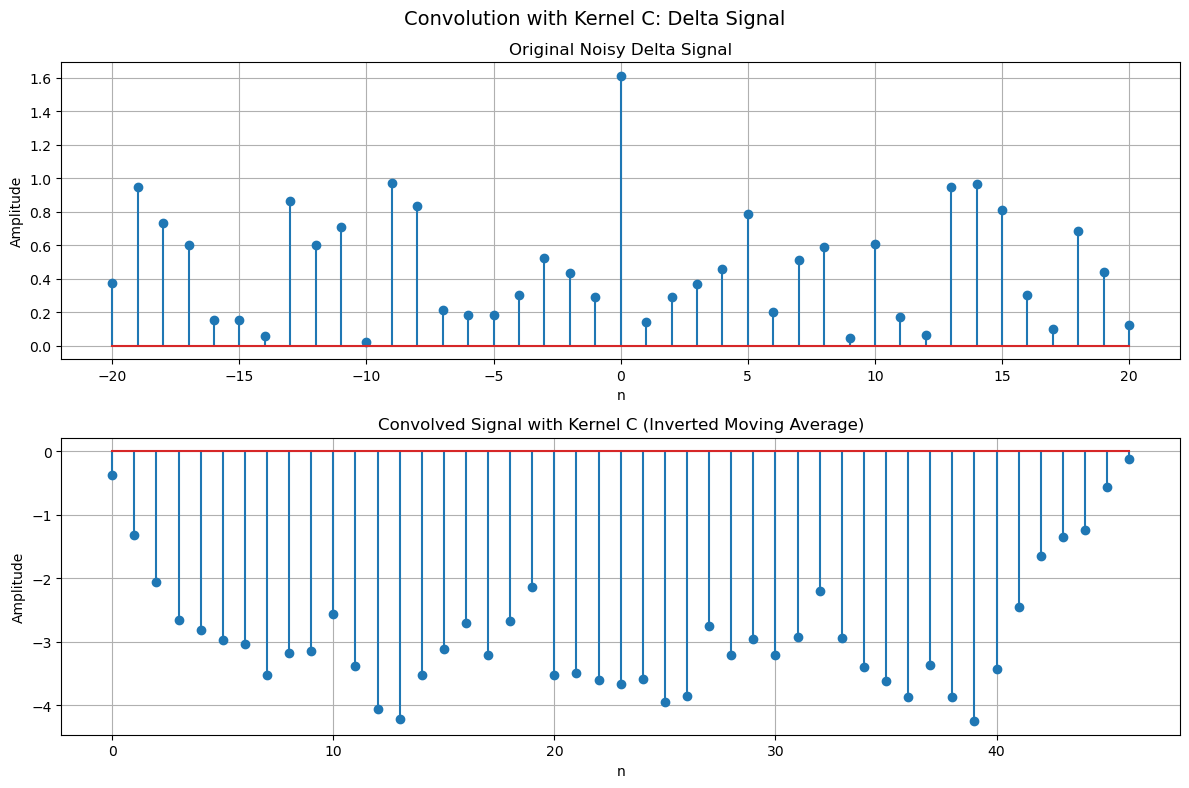

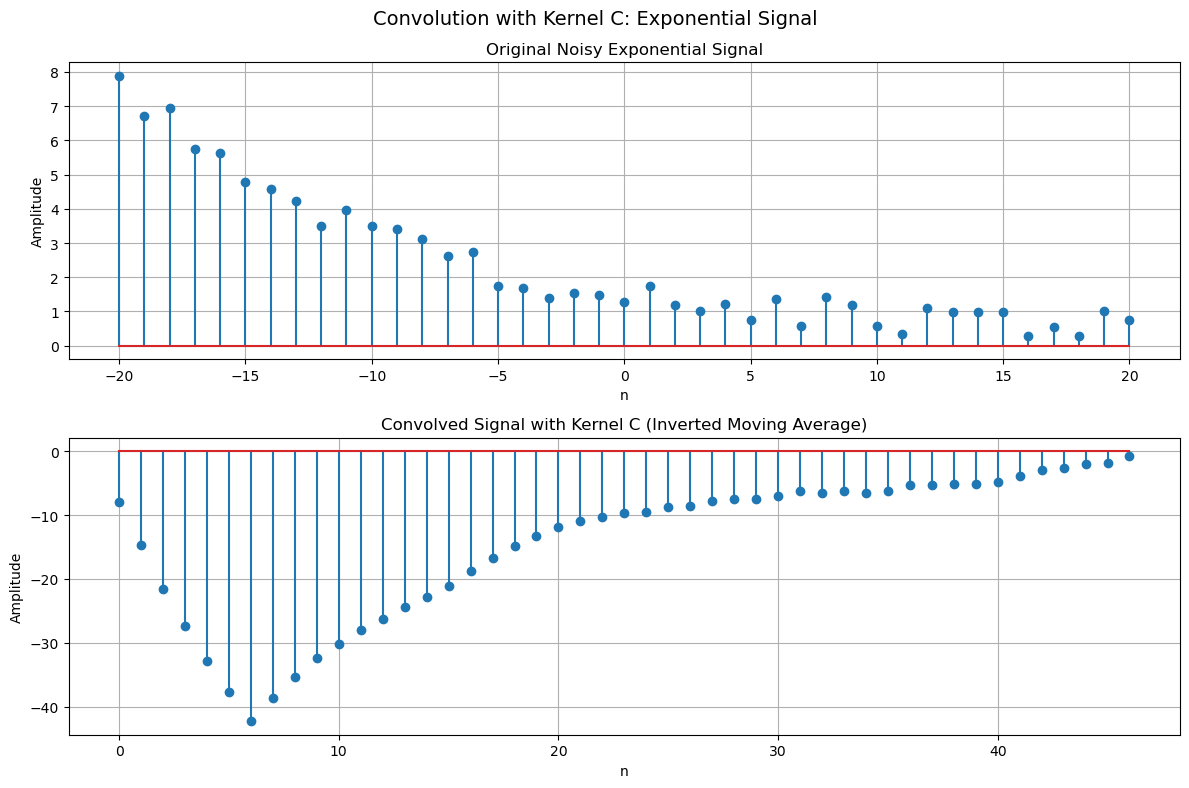

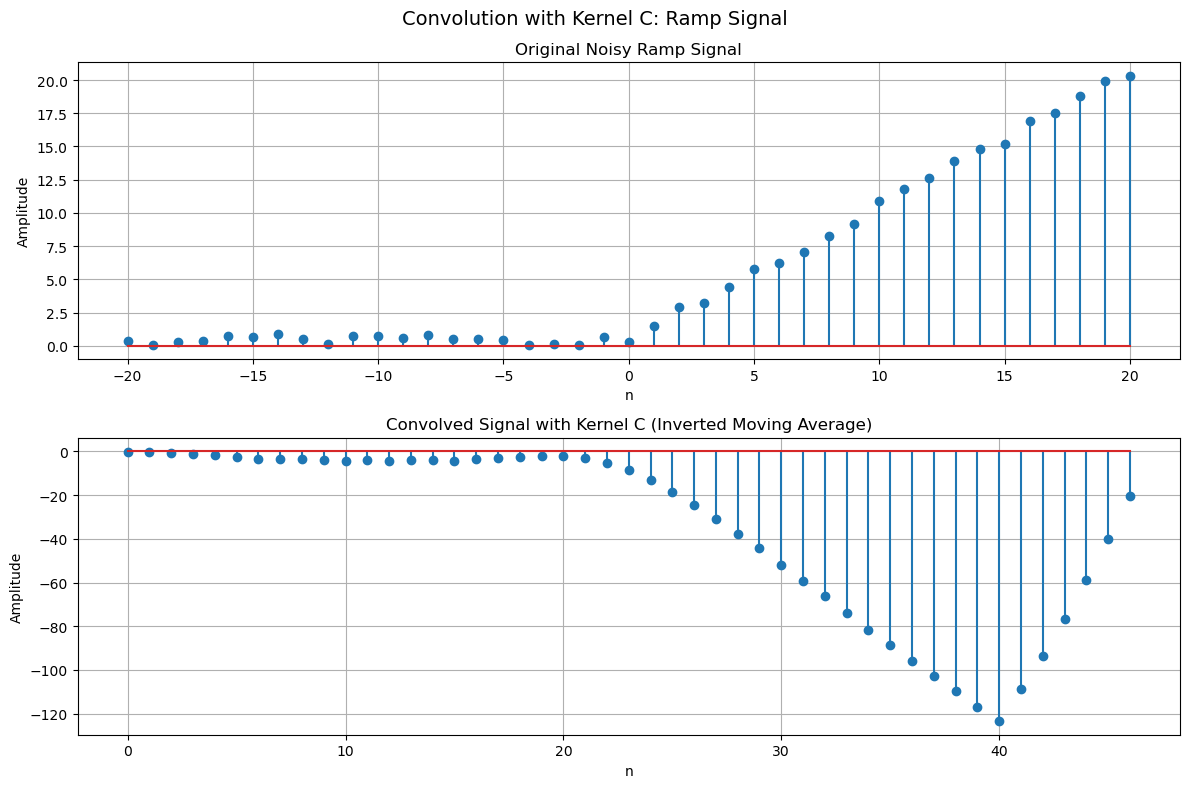

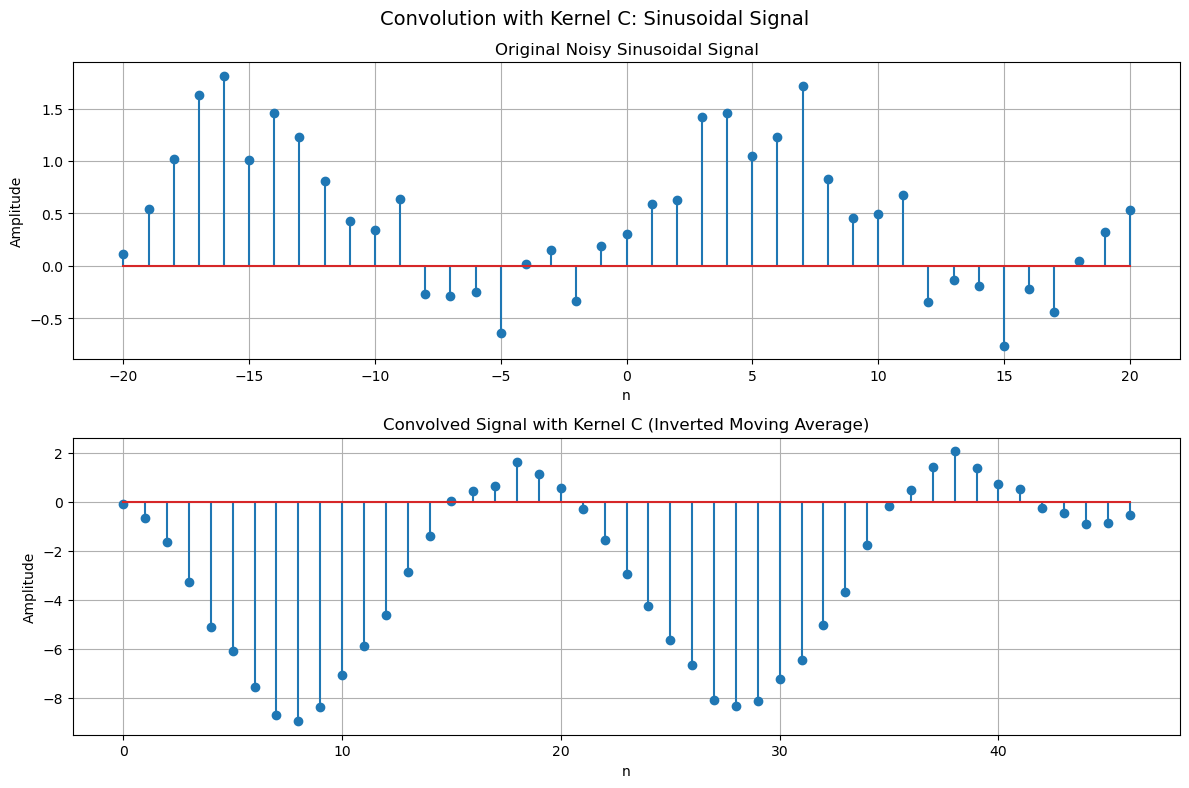

In [25]:
# Define impulse response C (Inverted Moving Average)
C = np.array([-1, -1, -1, -1, -1, -1, -1])
os.makedirs('outputs/kernel_C', exist_ok=True)

# Convolve each noisy signal with kernel C
convolved_signals_C = {}
for name, signal in signals.items():
    convolved = convolve(signal, C)
    convolved_signals_C[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel C: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel C (Inverted Moving Average)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_C/convolution_{name}_kernelC.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel C: [-1, -1, -1, -1, -1, -1, -1] — Inverted Moving Average', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_C.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/4_kernel_C_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel C `[-1, -1, -1, -1, -1, -1, -1]` is an **inverted moving average**. It performs the same averaging as Kernel B, but all weights are negative. The output is the **negative** (inverted) version of the smoothed signal.

**Comparison to original signals:**
- **Delta:** The spike becomes a broad **negative** bump — the inverse of Kernel B's output.
- **Exponential:** The noisy decay becomes a smooth **inverted** curve (rising from negative values toward zero).
- **Ramp:** The noisy rise becomes a smooth **inverted** ramp (descending).
- **Sinusoidal:** The oscillation is preserved but **flipped across the x-axis** and smoothed.

**Key takeaway:** Demonstrates that **kernel sign controls output polarity**. The filtering behavior is identical to Kernel B — same smoothing, same frequency response — but the output is mirrored. Useful for understanding how weight signs affect convolution output.

#### D = [0, 1, 0, -1, 0, 1, 0]


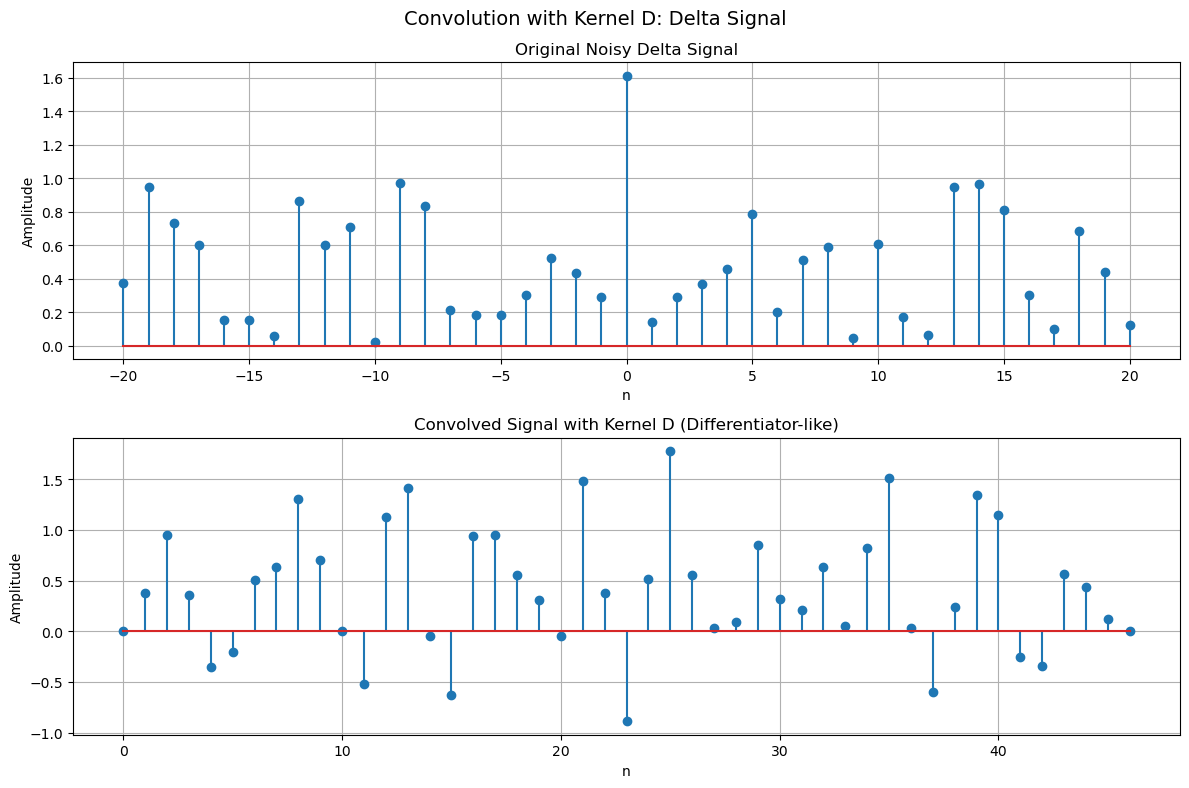

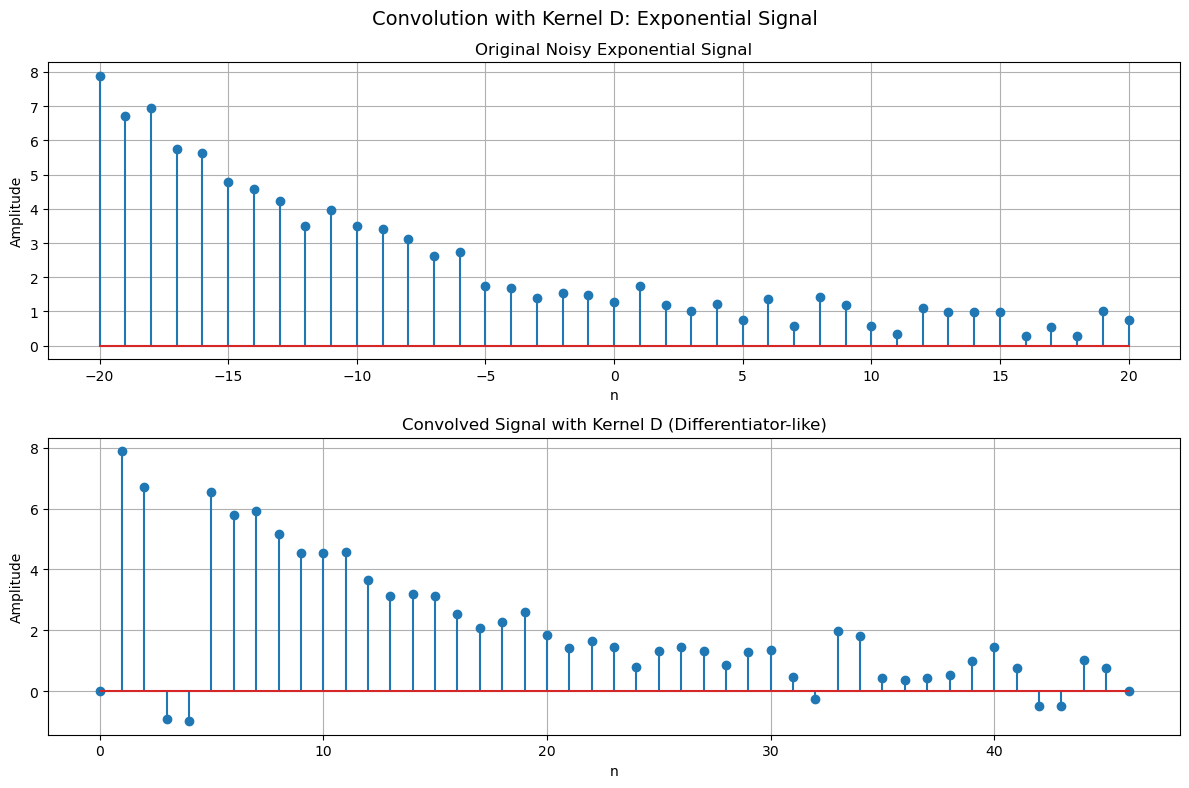

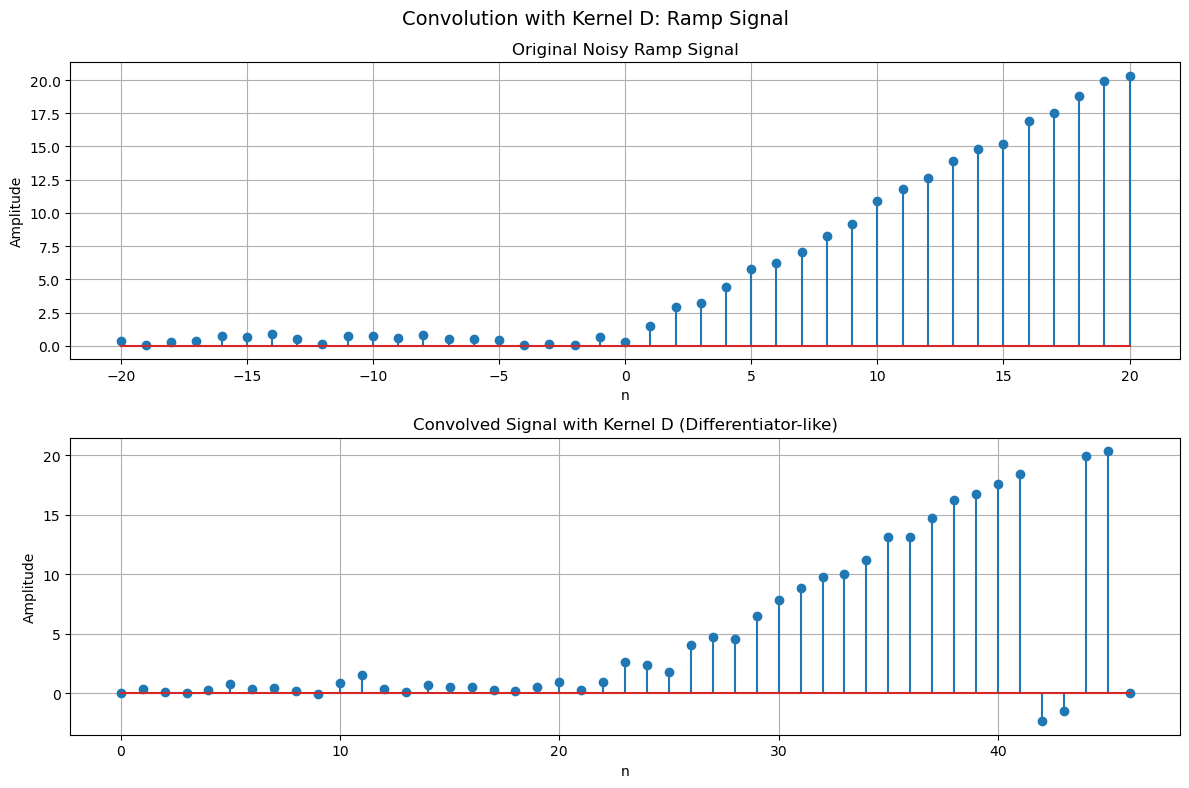

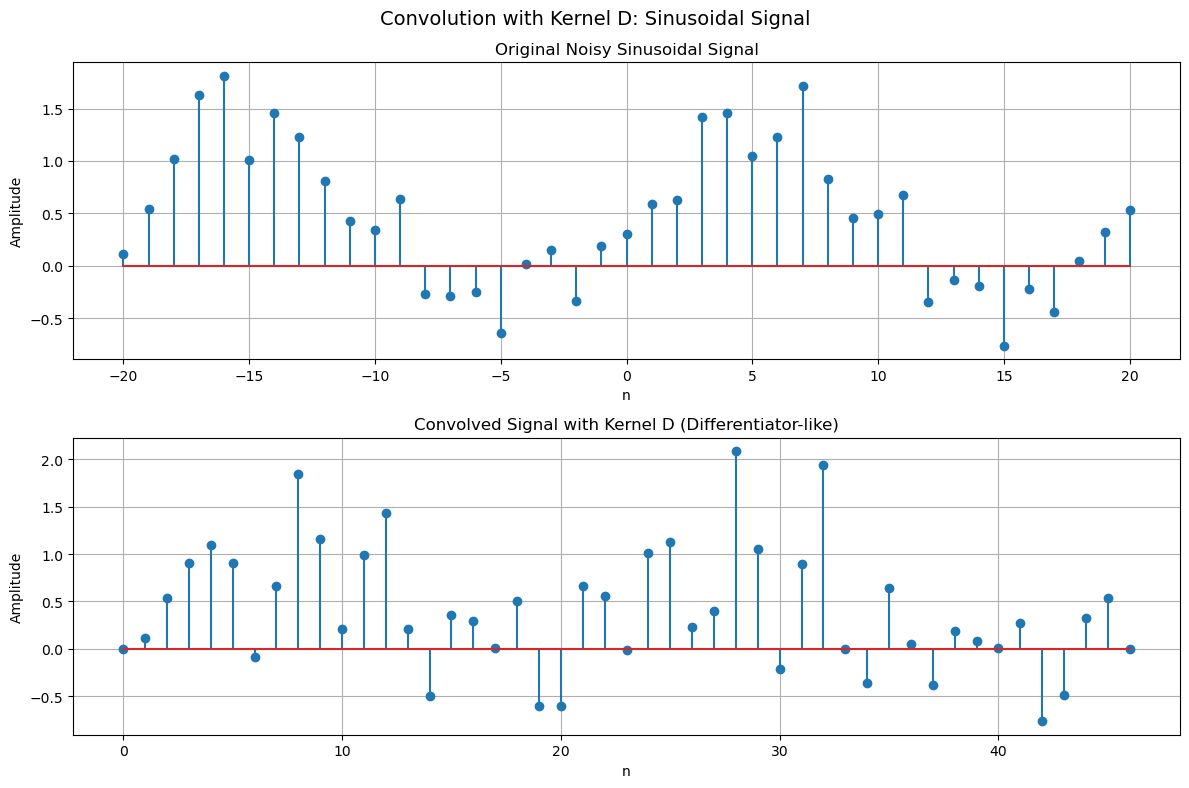

In [26]:
# Define impulse response D (Differentiator-like)
D = np.array([0, 1, 0, -1, 0, 1, 0])
os.makedirs('outputs/kernel_D', exist_ok=True)

# Convolve each noisy signal with kernel D
convolved_signals_D = {}
for name, signal in signals.items():
    convolved = convolve(signal, D)
    convolved_signals_D[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel D: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel D (Differentiator)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_D/convolution_{name}_kernelD.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel D: [0, 1, 0, -1, 0, 1, 0] — Differentiator/Edge Detector', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_D.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/4_kernel_D_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel D `[0, 1, 0, -1, 0, 1, 0]` is a **differentiator-like filter**. It computes weighted differences between neighboring samples, emphasizing rapid changes (edges) while suppressing constant or slowly varying components. This is a **band-pass filter**.

**Comparison to original signals:**
- **Delta:** Produces sharp spikes at the impulse location — the transition from 0→1 and 1→0 is amplified. The output highlights where the signal changes abruptly.
- **Exponential:** The smooth decay is largely suppressed. Only the noisy transitions remain visible — the underlying exponential trend is filtered out.
- **Ramp:** The constant slope produces a relatively constant output. Sudden jumps in noise are highlighted as spikes.
- **Sinusoidal:** The peaks and zero-crossings are amplified. The oscillatory nature is enhanced, making transitions more pronounced.

**Key takeaway:** Excellent for **edge detection** and **change detection**. It ignores smooth trends and focuses on discontinuities — useful for feature extraction but not for preserving the original signal shape.

#### E = [1, -1, 1, -1, 1, -1, 1]


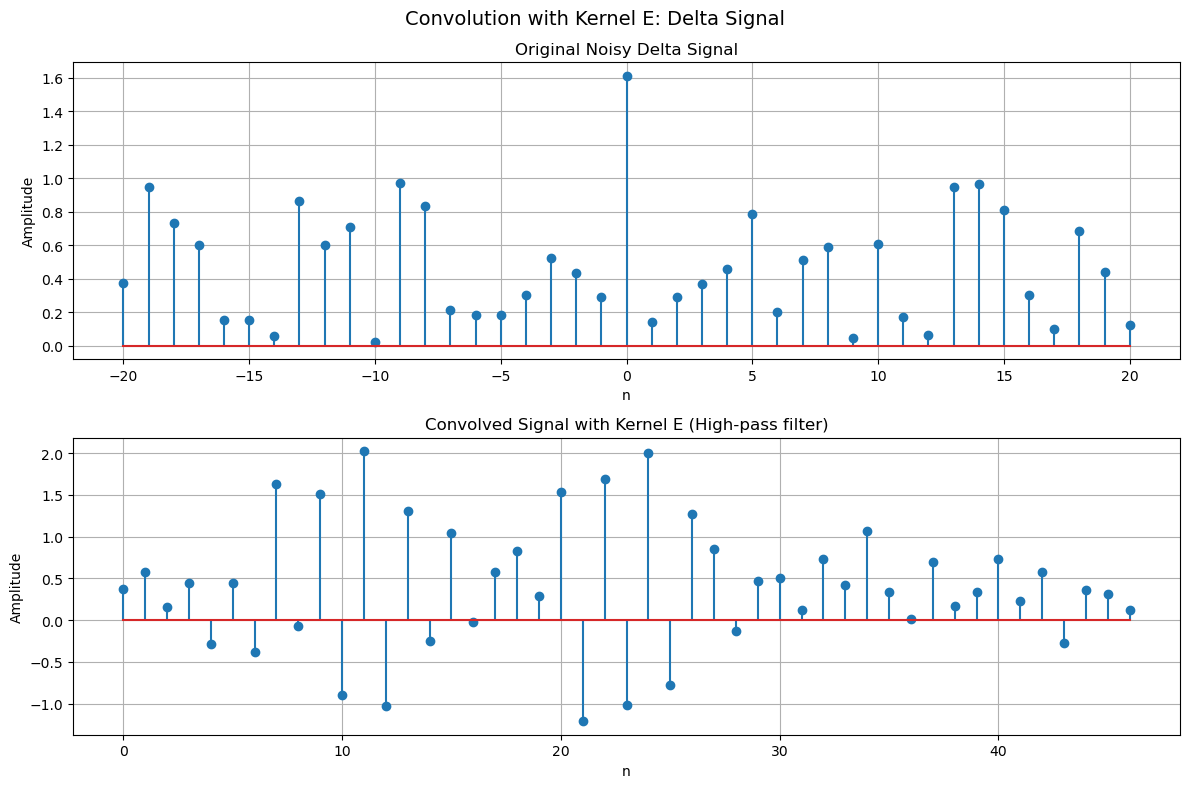

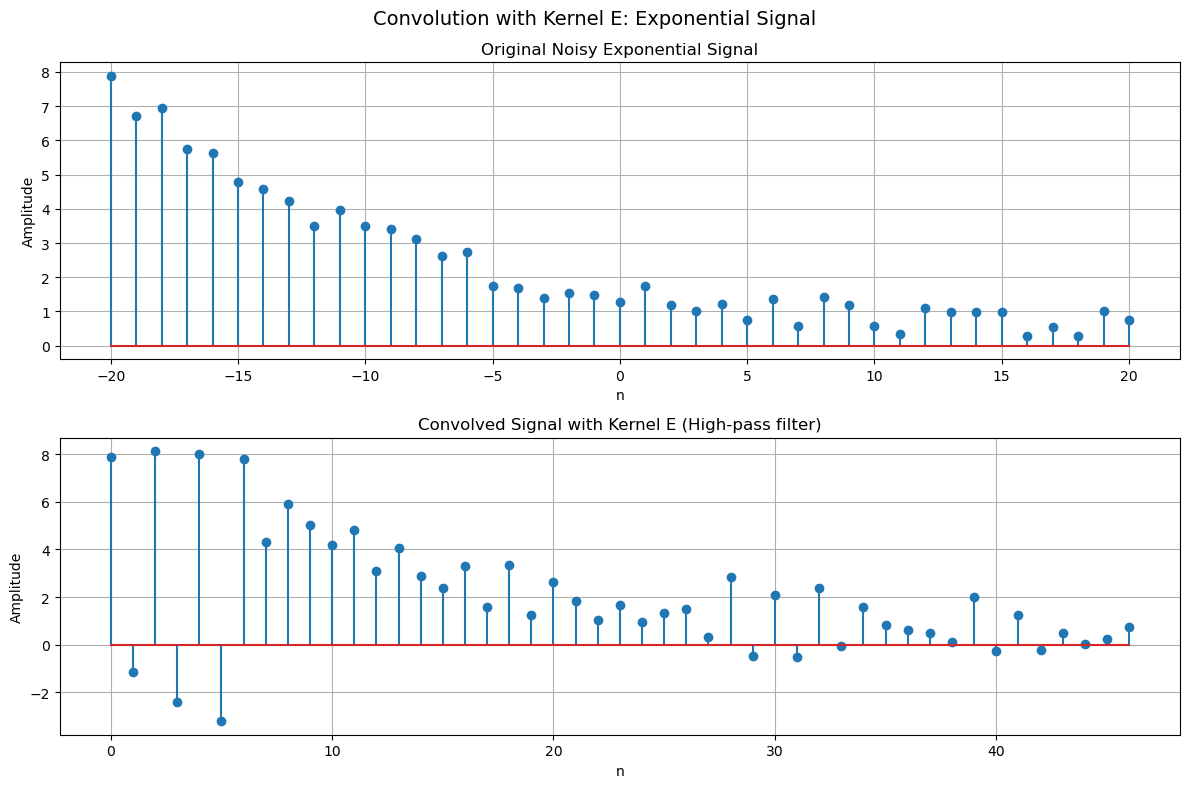

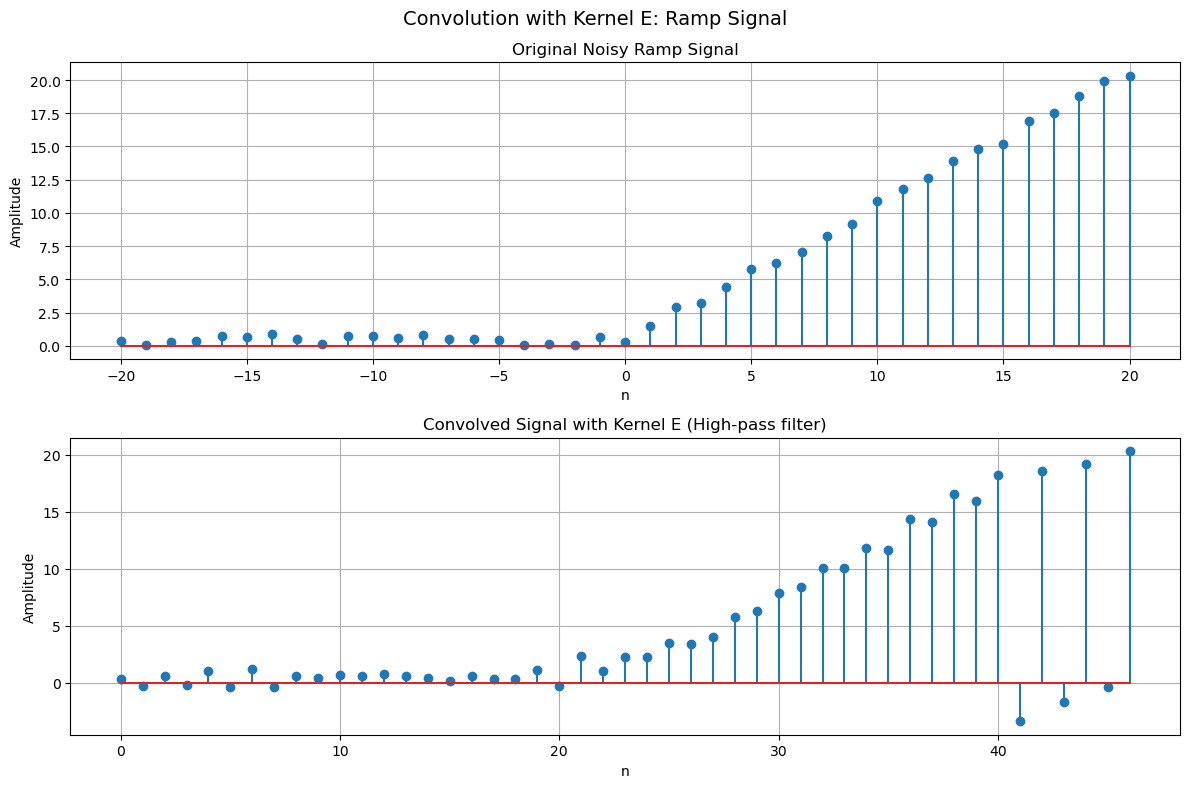

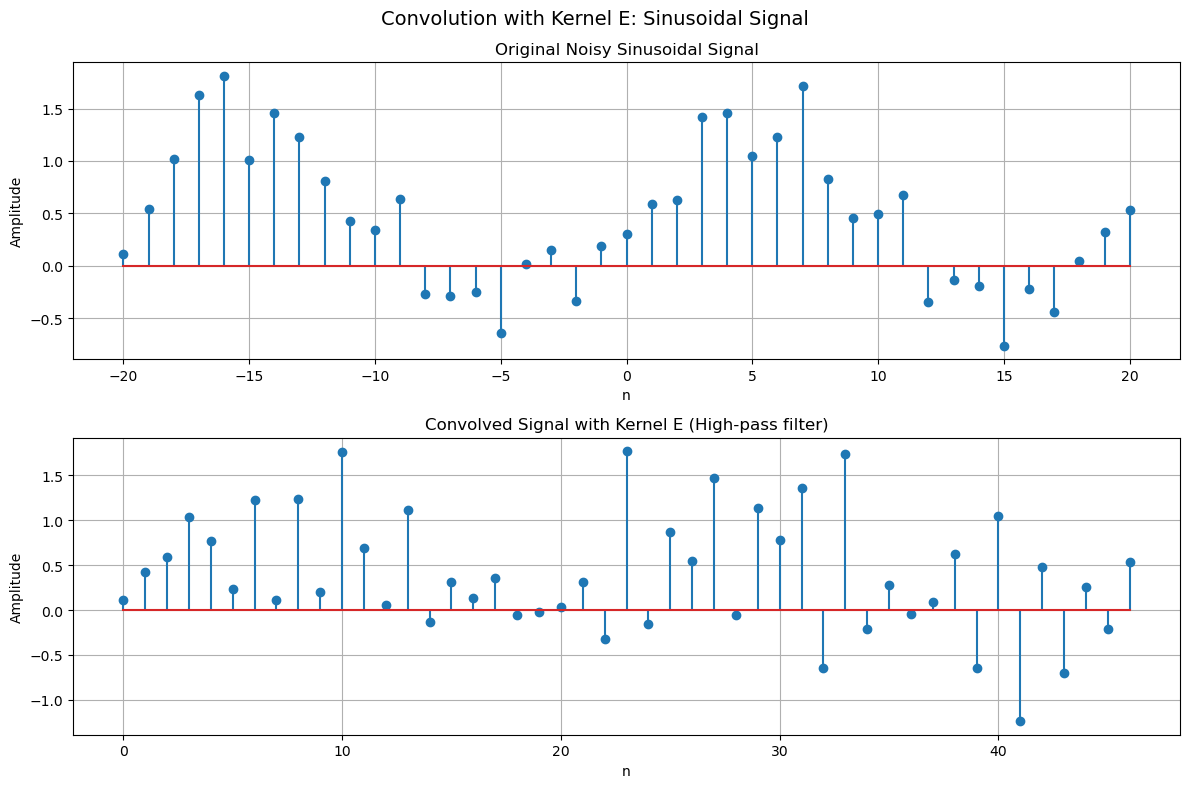

In [27]:
# Define impulse response E (High-pass filter)
E = np.array([1, -1, 1, -1, 1, -1, 1])
os.makedirs('outputs/kernel_E', exist_ok=True)

# Convolve each noisy signal with kernel E
convolved_signals_E = {}
for name, signal in signals.items():
    convolved = convolve(signal, E)
    convolved_signals_E[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel E: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel E (High-pass filter)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_E/convolution_{name}_kernelE.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel E: [1, -1, 1, -1, 1, -1, 1] — High-Pass Filter', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_E.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/4_kernel_E_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel E `[1, -1, 1, -1, 1, -1, 1]` is a **high-pass filter**. The alternating +1/-1 weights amplify high-frequency components (rapid changes) while suppressing low-frequency components (slow trends).

**Comparison to original signals:**
- **Delta:** The sharp spike is amplified and produces rapid oscillations in the output. High-frequency content dominates.
- **Exponential:** The smooth, slowly varying exponential is largely **suppressed**. Only noise remains visible — the signal itself is filtered out.
- **Ramp:** The linear trend is **suppressed**. Noise and sudden changes are amplified, making the output appear noisy.
- **Sinusoidal:** The oscillatory signal is **amplified**. The output has larger amplitude variations than the input, enhancing the high-frequency oscillation.

**Key takeaway:** Useful for **detecting fine details and rapid oscillations**, but **amplifies noise significantly**. Best suited for clean signals where high-frequency information is important. Not recommended for noisy data.

#### F = [0, 0.2, 0.4, 0.5, 0.4, 0.2, 0]

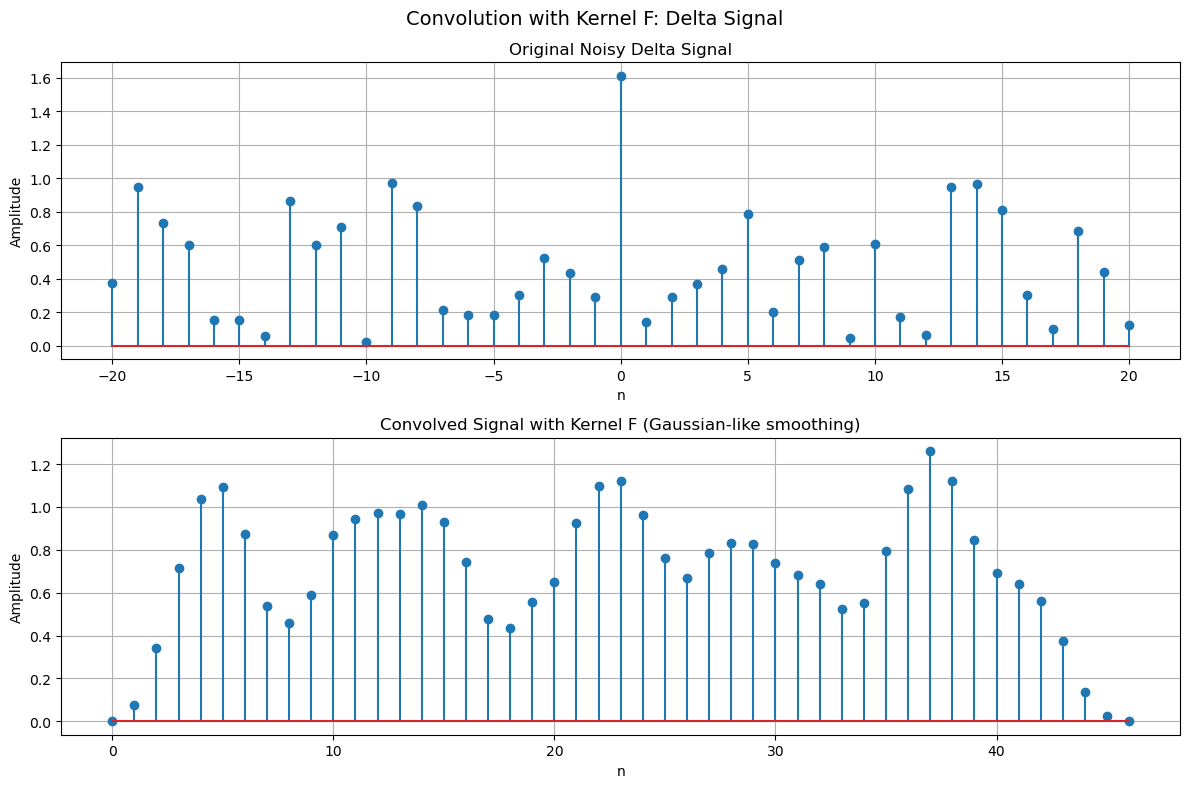

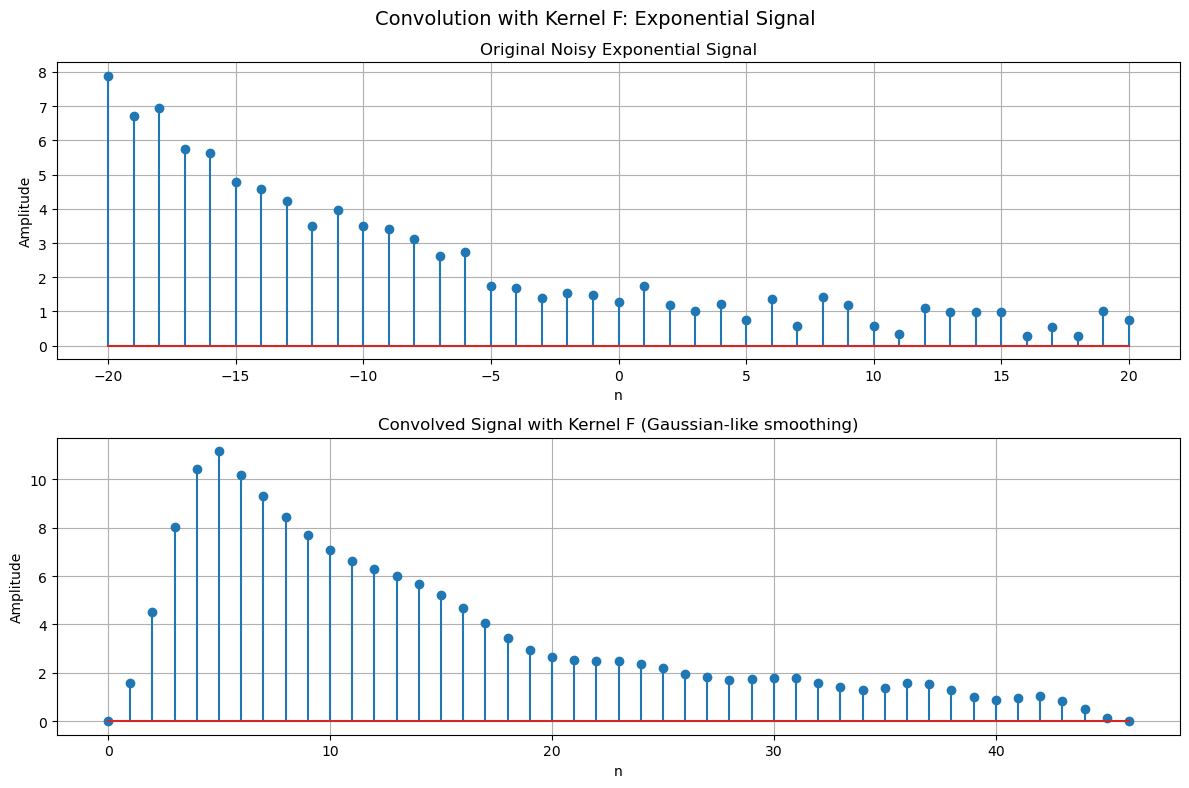

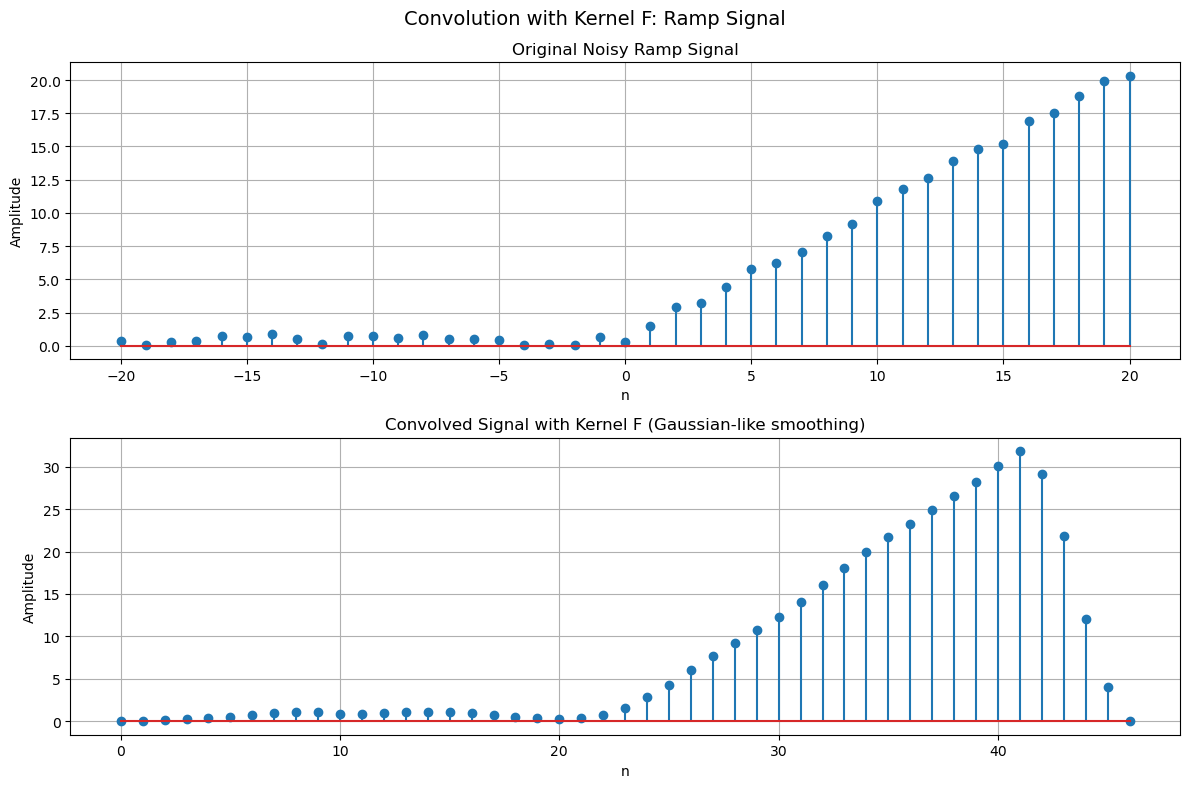

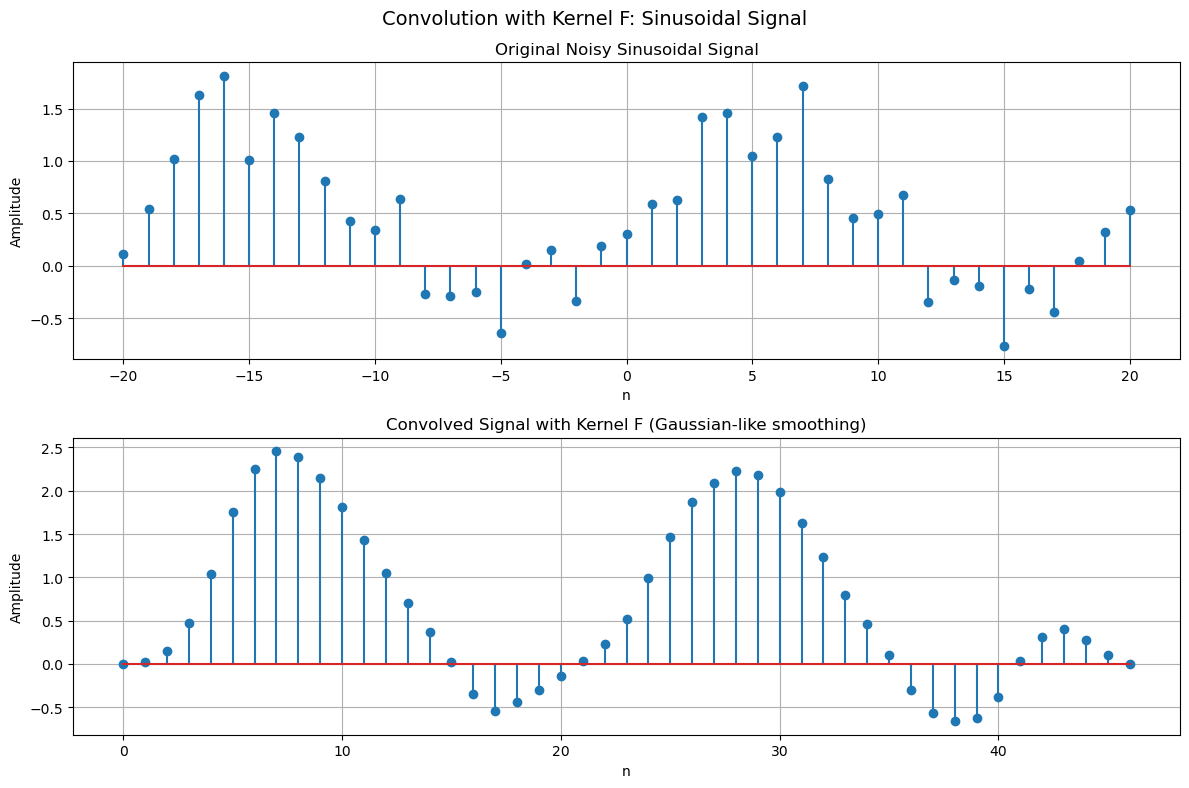

In [28]:
# Define impulse response F (Gaussian-like smoothing)
F = np.array([0, 0.2, 0.4, 0.5, 0.4, 0.2, 0])
os.makedirs('outputs/kernel_F', exist_ok=True)

# Convolve each noisy signal with kernel F
convolved_signals_F = {}
for name, signal in signals.items():
    convolved = convolve(signal, F)
    convolved_signals_F[name] = convolved
    n_conv = np.arange(len(convolved))
    
    # Save individual plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Convolution with Kernel F: {name.capitalize()} Signal', fontsize=14)
    axes[0].stem(n, signal)
    axes[0].set_title(f'Original Noisy {name.capitalize()} Signal')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    axes[1].stem(n_conv, convolved)
    axes[1].set_title(f'Convolved Signal with Kernel F (Gaussian smoothing)')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'outputs/kernel_F/convolution_{name}_kernelF.png', dpi=150, bbox_inches='tight')
    plt.close()

# Compiled 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convolution with Kernel F: [0, 0.2, 0.4, 0.5, 0.4, 0.2, 0] — Gaussian Smoothing', fontsize=14)
for ax, (name, convolved) in zip(axes.flatten(), convolved_signals_F.items()):
    n_conv = np.arange(len(convolved))
    ax.stem(n_conv, convolved)
    ax.set_title(f'{name.capitalize()} Signal')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
plt.tight_layout()
plt.savefig('outputs/4_kernel_F_compiled.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analysis

**What happens:** Kernel F `[0, 0.2, 0.4, 0.5, 0.4, 0.2, 0]` is a **Gaussian-like smoothing filter**. The bell-shaped weighting means central samples contribute more than edge samples, providing smoother filtering than a uniform moving average.

**Comparison to original signals:**
- **Delta:** The spike becomes a smooth, bell-shaped curve — more natural-looking than Kernel B's rectangular response. The shape better approximates a Gaussian impulse response.
- **Exponential:** The decay curve is smoothed with **better preservation of the original shape** compared to Kernel B. The exponential trend is clearer with less distortion.
- **Ramp:** The noisy ramp becomes a clean linear rise with **minimal distortion**. The corners are preserved better than with Kernel B.
- **Sinusoidal:** The oscillation is preserved with **better amplitude fidelity** than Kernel B. The wave shape is cleaner and more natural.

**Key takeaway:** Provides the **best balance** between noise reduction and signal preservation. The bell-shaped weighting avoids the "ringing" artifacts that can occur with uniform averaging, making it the preferred choice for high-quality smoothing.

### 5. Compare and analyze the different effects of each impulse response to the original signal and each other.

## Summary of Analyses and Comparisons

This section summarizes the effects of all six impulse responses (Kernels A–F) on the four noisy signals, based on the detailed analyses from Sections 3 and 4.

---

### Kernel Classification

| Kernel | Weights | Type | Category | Primary Effect |
|--------|---------|------|----------|----------------|
| A | [0,0,0,1,0,0,0] | Delta/Identity | Pass-through | No change (signal shifted) |
| B | [1,1,1,1,1,1,1] | Uniform average | Low-pass | Smooths, reduces noise |
| C | [-1,-1,-1,-1,-1,-1,-1] | Inverted average | Low-pass (inverted) | Smooths + inverts polarity |
| D | [0,1,0,-1,0,1,0] | Differentiator | Band-pass | Detects edges/transitions |
| E | [1,-1,1,-1,1,-1,1] | Alternating weights | High-pass | Amplifies high-frequency |
| F | [0,0.2,0.4,0.5,0.4,0.2,0] | Gaussian weights | Low-pass | Smooths with bell-shaped weighting |

---

### Comparison by Signal Type

**Delta Signal (Impulse):**
- Kernel A: Preserves the spike (shifted) — no change
- Kernel B: Spreads into a broad rectangular bump
- Kernel C: Inverted rectangular bump
- Kernel D: Sharp spikes at transitions
- Kernel E: Rapid oscillations
- Kernel F: Smooth bell-shaped curve (best shape preservation among filters)

**Exponential Signal (Decay):**
- Kernel A: Identical decay curve (shifted)
- Kernel B: Smoother decay, noise reduced
- Kernel C: Inverted smooth decay
- Kernel D: Mostly suppressed (smooth signal has few transitions)
- Kernel E: Largely suppressed (low-frequency signal)
- Kernel F: Smooth decay with best shape fidelity

**Ramp Signal (Linear Rise):**
- Kernel A: Identical ramp (shifted)
- Kernel B: Smoother ramp, noise reduced
- Kernel C: Inverted smooth ramp
- Kernel D: Highlights slope changes and noise spikes
- Kernel E: Amplifies noise, suppresses linear trend
- Kernel F: Clean ramp with minimal distortion

**Sinusoidal Signal (Oscillation):**
- Kernel A: Identical oscillation (shifted)
- Kernel B: Smoothed oscillation, reduced amplitude variation
- Kernel C: Inverted oscillation
- Kernel D: Amplified peaks and zero-crossings
- Kernel E: Enhanced oscillations (high-frequency amplified)
- Kernel F: Best oscillation preservation with noise reduction

---

### Key Findings

1. **Noise Reduction vs. Edge Preservation:** Kernels B, C, and F reduce noise but blur edges. Kernel F (Gaussian) provides the best balance due to its bell-shaped weighting that minimizes distortion.

2. **Edge Detection:** Kernel D is most effective for detecting transitions and rapid changes. It suppresses smooth signals and highlights discontinuities — useful for feature extraction.

3. **High-Frequency Amplification:** Kernel E amplifies high-frequency components but also amplifies noise significantly. Best suited for clean signals where fine detail extraction is needed.

4. **Signal Preservation:** Kernel A (identity) preserves the signal perfectly. Among filtering kernels, Kernel F preserves signal structure best while reducing noise.

5. **Polarity Inversion:** Kernel C demonstrates that negative kernel weights invert the output polarity without changing the filtering behavior (same frequency response as Kernel B).

### 6. Provide your conclusion for each impulse response.

## Conclusions for Each Impulse Response

**Kernel A [0, 0, 0, 1, 0, 0, 0]:**
This delta function serves as an identity filter. It simply shifts the input signal without modifying its shape or amplitude. It is useful as a baseline reference to verify that the convolution implementation is correct. When the output matches the input (with only a time shift), the convolution is working as expected.

**Kernel B [1, 1, 1, 1, 1, 1, 1]:**
This uniform moving average filter is effective for noise reduction. By averaging neighboring samples, it suppresses random noise while preserving the general trend of the signal. However, it also blurs sharp edges and transitions, making it unsuitable for applications requiring precise edge information. It is best used for general-purpose smoothing of noisy signals.

**Kernel C [-1, -1, -1, -1, -1, -1, -1]:**
This is the inverted version of Kernel B. It produces the same smoothing effect but with opposite polarity. While not commonly used in practice, it demonstrates how the sign of kernel weights affects the output. It can be useful in differential or complementary filtering schemes.

**Kernel D [0, 1, 0, -1, 0, 1, 0]:**
This differentiator-like kernel is effective for edge detection and feature extraction. It responds strongly to transitions and rapid changes while suppressing constant or slowly varying components. It is useful in applications such as image edge detection, change detection in time-series data, and feature extraction for pattern recognition.

**Kernel E [1, -1, 1, -1, 1, -1, 1]:**
This high-pass filter amplifies high-frequency components and suppresses low-frequency content. It is useful for detecting rapid oscillations and fine details in signals. However, it also amplifies noise, so it should be used with caution on noisy data. Best suited for clean signals where high-frequency information is important.

**Kernel F [0, 0.2, 0.4, 0.5, 0.4, 0.2, 0]:**
This Gaussian-like smoothing filter provides the best balance between noise reduction and signal preservation. The bell-shaped weighting ensures that central samples have more influence than peripheral ones, resulting in smoother and more natural filtering compared to a uniform moving average. It is the preferred choice for applications requiring high-quality smoothing with minimal signal distortion.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.’s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.